# Introduction

Check the readme files in the folder to learn how to run scans and use defaults vs specify parameters

# Initialize

In [ ]:
cfg_file='sample_58_rfboard.yml' # Configuration file name
expt_path = 'C:\\_Data\\sample_58_new\\' # Experiment data path

max_t1 = 1 # Maximum T1 to consider when doing experiments (in us)

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

np.set_printoptions(legacy="1.25")
from qick import QickConfig

%load_ext autoreload
%autoreload 2

from slab_qick_calib.exp_handling.instrumentmanager import InstrumentManager
import slab_qick_calib.experiments as meas
from slab_qick_calib.calib import qubit_tuning, measure_func
from slab_qick_calib.calib.time_tracking import time_tracking
from slab_qick_calib.analysis import qubit_params 
from slab_qick_calib.helpers import rfboard, qick_check, config, handy



# Set color palette and font size
handy.config_figs()

In [ ]:
import qick
qick.__version__

## Set up new config 
Set to variables to True when setting up a new experiment config file. 

Note: make sure you set your ADC/DAC channels correctly. This code does not automatically fill in the ADC/DAC into your configuration file, so you should check yourself to make sure these values are correct. 

There are several elements that you may want to customize based on your readout parameters and coherence times. Check readme file config_manual.md

In [ ]:
# Set to false if you aren't creating a new one
new_config = False
new_folder = False

nqubits = 4
rfsoc_alias = 'bf1_soc'
t1_guess = 1 
ip = '10.108.30.23' # ip address of name server that rfsoc is connected to 
import os

configs_dir = os.path.join(os.getcwd(),'../', 'configs')

cfg_file_path = os.path.join(configs_dir, cfg_file)
images_dir = os.path.join(expt_path, 'images')
summary_dir = os.path.join(images_dir, 'summary')

if new_config or new_folder:
    if new_config:
        config.init_config(cfg_file_path, nqubits, type='full', aliases=rfsoc_alias, t1=t1_guess, ip=ip)
        config.init_model_config(cfg_file_path, nqubits)


    if not os.path.exists(expt_path):
        os.makedirs(expt_path)
        os.mkdir(images_dir)
        os.mkdir(summary_dir)

print('Data will be stored in', expt_path)

## Connect to RFSoC
Before running first cell, make sure a nameserver is running on the network, the Qick board is connected to it, and the ip address listed below matches that of the nameserver. 

You just need to run the first cell, then should be able to run any other cell in whatever order. 

If you need to restart the RFSoC, you should reconnect it to the nameserver and rerun this. 

In [ ]:
# Results config file
cfg_path = os.path.join(os.getcwd(),'..', 'configs', cfg_file)
auto_cfg = config.load(cfg_path)

# Connect to instruments
im = InstrumentManager(ns_address=auto_cfg['aliases']['ip'], port=8888)
print(im)

soc = im[auto_cfg['aliases']['soc']]
soccfg = QickConfig(soc.get_cfg())

cfg_dict = {'soc': soccfg, 'expt_path': expt_path, 'cfg_file': cfg_path, 'im': im}

In [19]:
print(soccfg)
# ADC 0 /1, 4, 5 
# DAC 0 / 1/ 2 /3  

QICK running on ZCU216, software version 0.2.360

Firmware configuration (built Sun Jun 15 22:25:25 2025):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 1, ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9338.880 Msps, fabric=583.680 MHz
		envelope memory: 65536 complex samples (7.018 us)
		32-bit DDS, range=9338.880 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9338.880 Msps, fabric=583.680 MHz
		envelope memory: 16384 complex samples (1.754 us)
		32-bit DDS, range=9338.880 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9338.880 Msps, fabric=583.680 MHz
		envelope memory: 32768 complex samples (3.509 us)
		32-bit DDS, range=9338.880 MHz
		DAC tile 0, blk 2 is 2_228 on JHC1, or QICK box DAC port 2
	3:	axis_signal_ge

## Check QICK issues

### Check mirror frequencies on qubit

In [ ]:
qick_check.check_freqs(0, cfg_dict)

### Check mirror frequencies from resonators

In [ ]:
qick_check.check_resonances(cfg_dict)

### Check sampling rates and minimum point spacing

In [ ]:
fnyq = cfg_dict['soc']._get_ch_cfg(ro_ch=0)['f_dds']/2
clock_tick = 1e3*cfg_dict['soc'].cycles2us(1)
print(f'ADC Nyquist frequency is {fnyq} MHz')
print(f'1 clock tick is {clock_tick} ns')

soccfg.cycles2us(1)*1e3

### Make sure you're not near the nyquist frequency of the ADC

In [ ]:
qick_check.check_adc(cfg_dict)

In [ ]:
cfg_dict['soc']

# RF Board Setup
Filters and attenuators are configured using the `rfboard` helper module.
Per-qubit settings are stored in the config file.

In [9]:
# Bypass all on-board filters (clean start)
rfboard.bypass_all_filters(soc, gen_channels=[2, 3], ro_channels=[10], cfg=auto_cfg)

In [10]:
# Apply per-qubit RF settings from config (filters + attenuators)
rfboard.apply_config_rf_settings(soc, auto_cfg, cfg_file=cfg_path)

In [11]:
print("read bias:", soc.rfb_get_bias(0))
print("set bias:", soc.rfb_set_bias(0,0.1))
print("read bias:", soc.rfb_get_bias(0))

read bias: 0.10000228881835938
set bias: 0.10000228881835938
read bias: 0.10000228881835938


In [12]:
soc.rfb_set_bias(3, float(0))

0.0

In [13]:
channel = 3
step = 0.02
max_val = 0.08
num_steps = int(max_val / step)
range = __builtins__.range
import time
for i in range(num_steps + 1):
    current = max_val - i * step
    print(f"--- {current:.1f}V ---")
    print("read bias:", soc.rfb_get_bias(channel))
    print("set bias:", soc.rfb_set_bias(channel, current))
    print("read bias:", soc.rfb_get_bias(channel))
    time.sleep(1)

--- 0.1V ---
read bias: 0.0
set bias: 0.07999420166015625
read bias: 0.07999420166015625
--- 0.1V ---
read bias: 0.07999420166015625
set bias: 0.06000518798828125
read bias: 0.06000518798828125
--- 0.0V ---
read bias: 0.06000518798828125
set bias: 0.039997100830078125
read bias: 0.039997100830078125
--- 0.0V ---
read bias: 0.039997100830078125
set bias: 0.020008087158203125
read bias: 0.020008087158203125
--- 0.0V ---
read bias: 0.020008087158203125
set bias: 0.0
read bias: 0.0


In [14]:
soc

<Pyro4.core.Proxy at 0x1fbcc7a1e20; connected IPv4; for PYRO:obj_50113c512c604b7883323e5fcba28afa@10.108.30.74:42537>

# Time of Flight (TOF)

TOF measures the time it takes for the signal to run through the wires. It will give us the time in clock ticks that we should wait to make a measurements 

 Use this to set trig_offset in config file

Activated qubit 0: ADC ch 0 (fc=0, bw=1000, bypass), DAC-ro ch 0 (fc=0, bw=1000, bypass), DAC-qb ch 1 (fc=0, bw=1000, bypass)


  0%|          | 0/1000 [00:00<?, ?it/s]

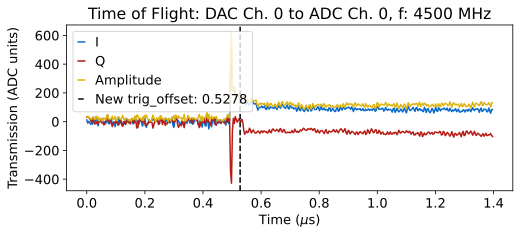

In [15]:
qubit_list = np.arange(3)
#rfboard.bypass_all_filters(soc, gen_channels=[2, 3], ro_channels=[1], cfg=auto_cfg)
auto_cfg = rfboard.activate_qubit_rf(0, soc, auto_cfg, cfg_file  =cfg_path)
qubit_list = [0]
for qi in qubit_list:  
        # tof=meas.ToFCalibrationExperiment(cfg_dict=cfg_dict, qi=qi)

        # Set frequency of choice and readout length (up to 13 us for standard ZCU216 firmware, readout)
        tof=meas.ToFCalibrationExperiment(cfg_dict=cfg_dict, qi=qi, params={'frequency':4500})

## Set trig_offset to point where signal has appeared, usually around 300-500 ns

In [ ]:
qubit_list=np.arange(1)
for qi in qubit_list: 
    auto_cfg = config.update_readout(cfg_path, 'trig_offset', 0.52, qi)

## Collect many time traces of TOF data (for examining measurement data)

check_e first prepares e state

In [ ]:
tof2d = meas.ToF2D(cfg_dict=cfg_dict, qi=qi, params={'expts_count':10000, 'readout_length': 13})
tof2d = meas.ToF2D(cfg_dict=cfg_dict, qi=qi, params={'expts_count':10000, 'readout_length': 13,'check_e':True})

# Resonator Spectroscopy 

Run resonator spectroscopy for all resonators by choosing a large frequency scan to look over. The scan will then find the different resonators and fill in the config file with their respective frequencies. In the autocalibration, there will be a finer sweep of each resonator to more accurately find its frequency. The frequencies are saved in <code>auto_cfg.device.readout.frequency</code>

## Coarse 

This will perform peak finding
Use params to specify frequency range, averaging, gain, expts. 
If gain is too high, you may be in punch out region, where resonators disappear, or above it 

### Res 

  0%|          | 0/1000000 [00:00<?, ?it/s]

Number of peaks: 0


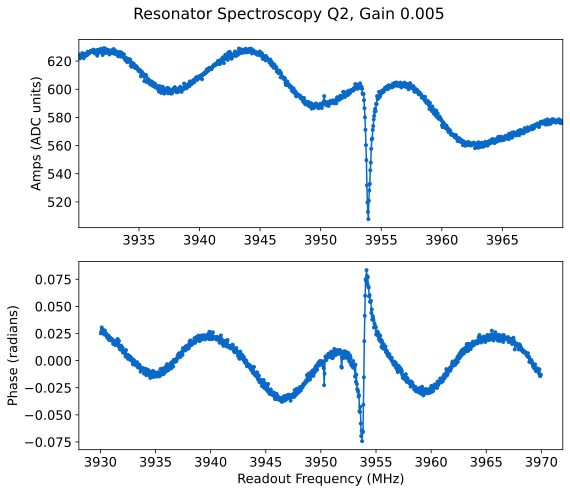

In [31]:
qi=2 # We only run this once for all qubits on a single feedline, this is a dummy value to make the scan work 
params={'start':3930, 'span':40, 'reps':1000, 'gain':0.005, 'expts':1000}
rspecc = meas.ResSpec(cfg_dict, qi=qi, style='coarse', progress=True, params=params)
res_values = rspecc.data['coarse_peaks']

In [ ]:
res_values = np.delete(res_values, 2)

## Fine

Activated qubit 1: ADC ch 0 (fc=0, bw=1000, bypass), DAC-ro ch 0 (fc=0, bw=1000, bypass), DAC-qb ch 1 (fc=0, bw=1000, bypass)


  0%|          | 0/750000 [00:00<?, ?it/s]

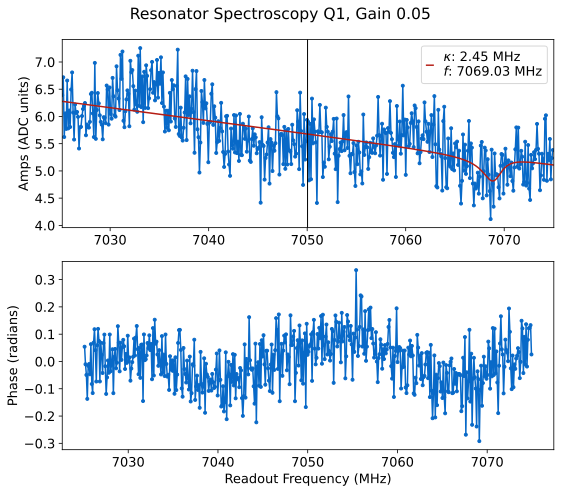

In [ ]:
update = False

# Per-qubit experiment params (RF attenuation/filter settings come from config)
qubit_list = [1]

for qi in qubit_list:
    # Activate this qubit's RF settings from config
    params={'span':50, 
            'reps':1500, 
            'gain':.5, 
            'expts':500}

    auto_cfg = rfboard.activate_qubit_rf(qi, 
                                         soc, 
                                         auto_cfg, 
                                         cfg_file=cfg_path,
                                         )

    rspec = meas.ResSpec(cfg_dict, qi=qi, params=params)

    if update:
        rspec.update()
        auto_cfg = config.load(cfg_path)

## Resonator Power Spectroscopy
Per-qubit RF overrides are passed explicitly since power spec uses
different attenuations than the standard config values.

Activated qubit 1: ADC ch 0 (fc=0, bw=1000, bypass), DAC-ro ch 0 (fc=0, bw=1000, bypass), DAC-qb ch 1 (fc=0, bw=1000, bypass)
High power peak [MHz]: 7125.0537
Low power peak [MHz]: 7047.6591
Lamb shift [MHz]: 77.3945


Traceback (most recent call last):
  File "C:\_Lib\python\qq\slab_qick_calib\analysis\fitting.py", line 1295, in fithanger
    pOpt, pCov = sp.optimize.curve_fit(
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\circu\anaconda3\envs\qick_calib\Lib\site-packages\scipy\optimize\_minpack_py.py", line 1029, in curve_fit
    raise RuntimeError("Optimal parameters not found: " + res.message)
RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.


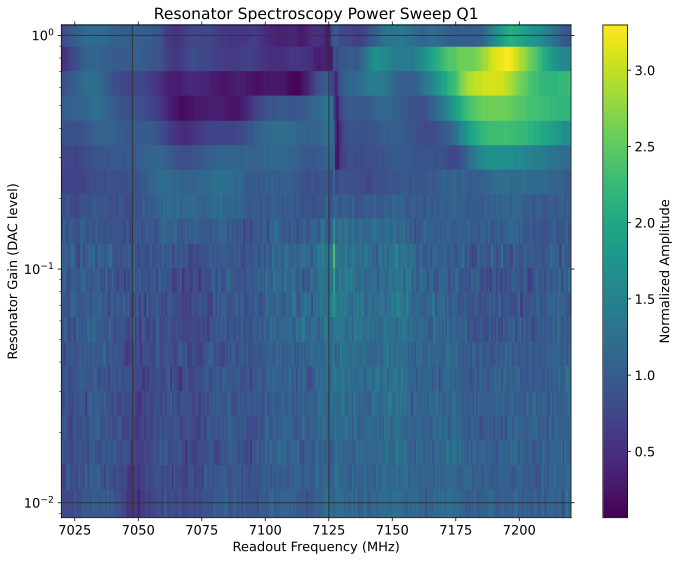

*Set cfg device.readout 1 lamb to 77.3945 from -3.63*


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
update = True

qubit_list = [1]

d = []
for qi in qubit_list:
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
    rpowspec = meas.ResSpecPower(cfg_dict, qi=qi, params={'span':200,'f_off':-70,'reps':1})
    d.append(rpowspec)
    if update:
        auto_cfg = config.update_readout(cfg_path, 'lamb', rpowspec.data['lamb_shift'], qi)
        # auto_cfg = config.update_readout(cfg_path, 'kappa', rpowspec.data['kappa'], qi)

## Tune resonator (flux)

In [ ]:
qubit_list = [2]
qi = 2

rfboard.setup_readout_chain(qi, soc, auto_cfg, bw_adc=1000, bw_dac=100, atten1_dac=30, atten2_dac=0, atten_adc=30)
params = {
    # inner 1D settings
    "span": 20, "expts": 500, "gain": 0.3,
    # outer DC sweep settings
    "start_dc": 0, "stop_dc": 0.5, "expts_dc": 101, 
    "dc_settle": 0.005,
    "dc_verify_print": True 
}
for qi in qubit_list: 
    res_exp_2 = meas.ResSpecFlux(cfg_dict, qi=qi, params=params, go=True, display=True)

# Qubit Spectroscopy

## Find qubits
More automated, zooms out and adds power if no peak visible. Best to use if you're feeling confident, otherwise use more manual stuff in next cell. 

In [ ]:
qubit_list= [0]

bad_qubits=[]
for qi in qubit_list:
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)

    status, ntries = qubit_tuning.find_spec(qi, cfg_dict, start='medium')
    if not status:
        bad_qubits.append(qi)

## General search, specify width 

style options: fine, medium, coarse, huge (will change scan width and power)

Uses config values of low_gain (gain to use for finest scan), which sets overall gain for device and spec_gain (set indepedently for each qubit) to decide how much power to apply

You may also just want to do this fully manually by specifiying params. 

In [ ]:
update=True
span = 150
qubit_list = [2]
for qi in qubit_list:
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
    
    # set up filter and attenuation  
    #filter_center_freq = 5620
    #bw = 500
    #rfboard.setup_qubit_drive_chain(qi, soc, auto_cfg, bw=bw)#, center_freq=filter_center_freq)
    
    #start_freq = filter_center_freq - span/2
    #params={'start':start_freq, 'span':span, 'gain':0.02, 'expts':100,  'sep_readout': True, 'length':1, 'readout_length':1, 'reps':15000}
    params={'length':2,'span':100,'gain':0.002}
    qspec=meas.QubitSpec(cfg_dict, qi=qi, style='medium', params=params)

    if update and qspec.status: 
        auto_cfg = config.update_qubit(cfg_path, 'f_ge', qspec.data["best_fit"][2], qi)
        auto_cfg = config.update_qubit(cfg_path, 'kappa',2*qspec.data["best_fit"][3], qi)
    elif update:
        print(f'Bad qubit! qi={qi}')

### Loop

In [ ]:
update = True
qubit_list = [0]

# Sweep from 4000 MHz to 8000 MHz
center_freqs = np.arange(4000, 8000 + 1, 250)  # adjust step size as needed

for qi in qubit_list:

    bw = 500

    # Readout chain only needs to be configured once
    rfboard.setup_readout_chain(
        qi,
        soc, auto_cfg,
        bw_adc=500,
        bw_dac=100,
        atten1_dac=30,
        atten2_dac=30,
        atten_adc=30
    )

    for filter_center_freq in center_freqs:

        start_freq = filter_center_freq - bw / 2

        params = {
            'start': start_freq,
            'span': bw,
            'gain': 0.1,
            'expts': 500,
            'sep_readout': False
        }

        qspec = meas.QubitSpec(
            cfg_dict,
            qi=qi,
            style='fine',
            params=params
        )

        if update and qspec.status:
            auto_cfg = config.update_qubit(
                cfg_path,
                'f_ge',
                qspec.data["best_fit"][2],
                qi
            )
            auto_cfg = config.update_qubit(
                cfg_path,
                'kappa',
                2 * qspec.data["best_fit"][3],
                qi
            )
        elif update:
            print(f'Bad qubit! qi={qi}, center={filter_center_freq}')

## Fast Flux 

### Single scan with flux=True

In [ ]:
span = 150
qubit_list = [2]
for qi in qubit_list:
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
    
    params={'length':2,'span':300,'expts':400,'gain':0.002,'flux':True, 
            'flux_gain':-0.25,'start':2850,'rounds':2}
    qspec=meas.QubitSpec(cfg_dict, qi=qi, style='fine', params=params)


### Sweep gain between two values and track resonant value


In [ ]:
# qsff = meas.QubitSpecFastFlux(cfg_dict, qi=2, params={
#     'gain_start': 0.4, 'gain_stop': -0.38, 'expts_gain': 200,
#     'span': 250, 'expts': 200, 'reps': 1000, 'rounds': 1,'final_delay':6,
#     "start_center_freq":3260, 'gain': 0.002, 'length': 1,'pulse_type':'const','readout_length': 1.4, 'sep_readout': True,
# })
qsff = meas.QubitSpecFastFlux(cfg_dict, qi=2, params={
    'gain_start': 0, 'gain_stop': 1, 'expts_gain': 1000,
    'span': 50, 'expts': 200, 'reps': 2500, 'rounds': 1,'final_delay':6,
    "start_center_freq":3400, 'gain': 0.006, 'length': 2,'pulse_type':'const','readout_length': 1.2, 'sep_readout': True,
})
# After completion, get the quadratic coefficients for use in T1FastFlux:
a, b, c = qsff.data["freq_coeffs"]


In [ ]:
qsff.analyze(fit_model='transmon');
qsff.display()

In [ ]:
qsff.update()

In [ ]:
from slab_qick_calib.analysis import fitting
pOpt, pCov, _ = fitting.fit_transmon_flux(
    qsff.data['gain_pts'][mask], qsff.data['qubit_freq_list'][mask], 140,
)

In [ ]:
qsff = meas.QubitSpecFastFlux(cfg_dict, qi=2, params={
    'gain_start': 0.1537, 'gain_stop': -0.28, 'expts_gain': 500,
    'span': 25, 'expts': 50, 'reps': 2000, 'rounds': 1,'lin_freq':True,'direction':'neg',
    "start_center_freq":3466, 'gain': 0.002, 'length': 1,'pulse_type':'const','readout_length': 1.4, 'sep_readout': True,
})

# After completion, get the quadratic coefficients for use in T1FastFlux:
a, b, c = qsff.data["freq_coeffs"]

In [ ]:
from scipy.interpolate import interp1d

gain_pts = qsff.data['gain_pts']
xpts_all = qsff.data['xpts']
avgi_all = qsff.data['avgi']

freq_trimmed = [np.asarray(x) for x in xpts_all]
avgi_trimmed = [np.asarray(a) for a in avgi_all]
f_min = min(f.min() for f in freq_trimmed)
f_max = max(f.max() for f in freq_trimmed)
n_common = max(len(f) for f in freq_trimmed)
common_freq = np.linspace(f_min, f_max, n_common)

avgi_interp = np.full((len(gain_pts), n_common), np.nan)
for i, (f, a) in enumerate(zip(freq_trimmed, avgi_trimmed)):
    mask = (common_freq >= f.min()) & (common_freq <= f.max())
    interp_fn = interp1d(f, a, kind="linear", bounds_error=False, fill_value=np.nan)
    avgi_interp[i, mask] = interp_fn(common_freq[mask])

# Sort so larger gain is on top
sort_idx = np.argsort(gain_pts)
gain_sorted = gain_pts[sort_idx]
avgi_sorted = avgi_interp[sort_idx]

fig, ax = plt.subplots(figsize=(10, 6))
extent = [common_freq[0], common_freq[-1], gain_sorted[0], gain_sorted[-1]]
ax.imshow(avgi_sorted, aspect='auto', origin='lower', extent=extent, cmap="viridis", interpolation='nearest')
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Flux Gain")

In [ ]:
qsff = meas.QubitSpecFastFlux(cfg_dict, qi=2, params={
    'expts_gain': 120, 'span': 250, 'expts': 150, 'reps': 2000, 'rounds': 1,'lin_freq':True,'direction':'neg','freq_span':1100,
    "start_center_freq":3465, 'gain': 0.0848, 'length': 0.01,'pulse_type':'gauss','readout_length': 1, 'sep_readout': True,'flux_readout_wait':0.1,'flux_trail_time':0.1,
})

# After completion, get the quadratic coefficients for use in T1FastFlux:
a, b, c = qsff.data["freq_coeffs"]

In [ ]:
qs_list=[]
lead_times = [0.002, 0.01, 0.03, 0.1, 0.3, 1]
for l in lead_times:
    qsff = meas.QubitSpecFastFlux(cfg_dict, qi=2, params={
        'gain_start': 0.2, 'gain_stop': -0.3, 'expts_gain': 25,'rounds':2,
        'span': 200, 'expts': 200, 'reps': 3000, 'flux_lead_time':l,
        "start_center_freq":3465, 'gain': 0.0848, 'length': 0.01,'pulse_type':'gauss','readout_length': 1.4, 'sep_readout': True,
    })
    qs_list.append(qsff)

In [ ]:
qs_list2=[]
lead_times = [0.1, 0.3, 1, 3, 10, 30]
#lead_times = [30]
for l in lead_times:
    qsff = meas.QubitSpecFastFlux(cfg_dict, qi=2, params={
        'gain_start': 0.2, 'gain_stop': -0.4, 'expts_gain': 50,
        'span': 200, 'expts': 200, 'reps': 1000, 'flux2_length':l, "flux2":True, 
        "final_delay":10,
        "start_center_freq":3465, 'gain': 0.0848, 'length': 0.01,'pulse_type':'gauss',
        'readout_length': 1.4, 'sep_readout': True,
    })
    qs_list2.append(qsff)

In [ ]:
plt.figure()
import seaborn as sns
sns.set_palette("viridis", n_colors=len(qs_list))
for qsff in qs_list2:
    plt.plot(qsff.data['gain_pts'], qsff.data['qubit_freq_list'], label=f"{qsff.cfg.expt['flux_trail_time']} us")

#plt.plot(qs_list2[0].data['gain_pts'], qs_list2[0].data['qubit_freq_list'], label=f"{qs_list2[0].cfg.expt['flux_lead_time']} us, 50 us final")

plt.xlabel("Flux Gain")
plt.ylabel("Qubit Frequency (MHz)")
plt.title("Varying flux pulse length")
plt.legend()
plt.savefig('qubit_spec_sweep_flux_middlee_time_long_final.png', dpi=300)

### Any 2D sweep

In [ ]:
from slab_qick_calib.analysis.fitting import flux_converter_from_config
cfg = config.load(cfg_path)
converter = flux_converter_from_config(cfg.hw.soc.dacs.flux, cfg.device.qubit, qi=2, direction='neg')
gain = converter.freq_to_gain(23000)

In [ ]:
# Sweep any other parameter, e.g. pulse length
qi = 2

params = {
    'flux_gain': -0.25, 'span': 100, 'expts': 80, "start":2970, 'gain': 0.1, 
    'length': 0.01,'pulse_type':'gauss', "sweep_var": "flux_lead_time",
    "sweep_pts": np.logspace(-2, 2, 30), "final_delay":10,"flux_negative_reset":True,
    "sweep_label": "Flux Lead Time (us)","log_sweep":True
}
expt = meas.QubitSpecFluxSweep(cfg_dict, qi=qi, params=params)

In [ ]:
expt.analyze(alpha0=1.0)
expt.update()

In [ ]:
data = expt.analyze(
    n_exp=3, t_range=(0.01, 50), flux_gain_target=-0.25,
    s0=1.0,  # constrain s(0) = α₀ + Σαᵢ = 1
    outlier_sigma=2)

In [ ]:
expt.update()

In [ ]:
qsfs = meas.QubitSpecFluxSweep(cfg_dict, qi=2, params={
    "sweep_var": "flux_lead_time",
    "sweep_pts": np.logspace(-2, 1.25, 30),
    'length': 0.01,'pulse_type':'gauss',
    'flux_gain': -0.25, 'span': 120,
     'expts': 80, "start_center_freq":3000, 'gain': 0.1,
    "predistorted": True,
    "flux_slow_only": False,"flux_negative_reset":True,
    "sweep_label": "Flux Lead Time (us)","log_sweep":True
})

In [ ]:
qsfs.analyze()
qsfs.update()

In [ ]:
qsfs = meas.QubitSpecFluxSweep(cfg_dict, qi=2, params={
    "sweep_var": "flux_gain",
    "sweep_pts": np.linspace(-.3, 0, 20),
    'length': 0.01,'pulse_type':'gauss',
     'span': 160,
     'expts': 80, "start_center_freq":3400, 'gain': 0.1,
    "predistorted": True,
    "flux_slow_only": False,"flux_negative_reset":True,
    "sweep_label": "Flux Lead Time (us)"
})

In [ ]:
expt = meas.QubitSpec(cfg_dict, qi=2, go=True, params={
    "flux_gain": -0.125,
    "start": 2700,       # now respected after the fix
    "span": 700,"flux_lead_time":0.1,
    "expts": 200,"flux":True,
    'length': 0.01,'pulse_type':'gauss',"gain": 0.1,
    "flux_slow_only": False,
})

### distorted pulse

In [ ]:
expt = meas.QubitSpecPredist(cfg_dict, qi=2, go=False, params={
    "flux_gain": -0.25,
    "start": 2850,       # now respected after the fix
    "span": 300,"flux_lead_time":1,
    "expts": 200,
    'length': 0.01,'pulse_type':'gauss',"gain": 0.1,
    "flux_slow_only": False,
})

#env = expt.plot_envelope()


In [ ]:
env = expt.plot_envelope()

In [ ]:
# Sweep any other parameter, e.g. pulse length
qi = 2

params = {
    'flux_gain': -0.25, 'span': 200, 'expts': 200, "start":2980, 'flux':True,
    'length': 0.01,'pulse_type':'gauss', "sweep_var": "gain","flux_lead_time":50,
    "sweep_pts": np.linspace(0.04, 0.5, 12),
    "sweep_label": "Gain","log_sweep":False
}
expt = meas.QubitSpecFluxSweep(cfg_dict, qi=qi, params=params)

In [ ]:
plt.figure()
amps = [expt.data['fit_params_list'][i][1] for i in range(len(expt.data['fit_params_list']))]
plt.plot(amps)

## DC Flux sweep

Flux sweep resonator first, and then use the values to guide qubit sweep

In [ ]:
fluxes = np.arange(0,0.2,0.05)
fluxes = list(fluxes)
qi = 2
for flux in fluxes:
    print(f"Setting flux bias to {flux:.2f} V")
    soc.rfb_set_bias(3, flux)
    time.sleep(0.1)  # wait for bias to settle


    #Resonator measurement
    # Per-qubit experiment params (RF attenuation/filter settings come from config)

    # Activate this qubit's RF settings from config
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)

    rspec = meas.ResSpec(cfg_dict, qi=qi, params={'span':'kappa',})
    rspec.update()
    auto_cfg = config.load(cfg_path)
    
    filter_start_freq = 3420
    bw = 1150
    # set up filter and attenuation  
    rfboard.setup_qubit_drive_chain(qi, soc, auto_cfg, bw=bw, atten1_dac=30, atten2_dac=25, center_freq=filter_center_freq-bw/2)
    start_freq = filter_start_freq
    params={'start':start_freq, 'span':100, 'gain':0.5, 'expts':200, 'reps':1000, 'rounds':10, 'sep_readout': True, 'length':1, 'readout_length':8}
    
    qspec=meas.QubitSpec(cfg_dict, qi=qi, style='fine', params=params)
    plt.show()
    

In [ ]:

qubit_list = [2]
qi = 2

filter_center_freq = 3424
rfboard.setup_qubit_drive_chain(qi, soc, auto_cfg, bw=750, atten1_dac=30, atten2_dac=25, center_freq=filter_center_freq)
        
params = {
    # inner 1D settings
    "span": 100, "expts": 200, "reps": 1000, "gain": 0.5,
    'rounds': 100,
    # outer DC sweep settings
    "dc_start": -0.035, "dc_stop": 0.2, "expts_dc": 236,
    "bias_chan": 3,         
    "recenter_res": True,         # enable inline recentering
    "recenter_res_span": 10,       # MHz span around current f0
    "recenter_res_expts": 101,    # points per ResSpec
    "dc_settle": 0.1, # wait time after setting DC value before next measurement
    "dc_verify_print": True, # toggle to True if you want readback per row
    'sep_readout': True, 'length':8, 'readout_length':8
}
for qi in qubit_list: 
    exp = meas.QubitSpecFlux(cfg_dict, qi=qi, params=params, go=True, display=True)
    # data is in exp.data; plot saved via exp.display()


In [ ]:
print("read bias:", soc.rfb_get_bias(channel))

In [ ]:
print("set bias:", soc.rfb_set_bias(channel, 0.0))

Ramp down

In [ ]:
channel = 3
step = 0.01
max_val = 0.2
num_steps = int(max_val / step)
range = __builtins__.range
import time
for i in range(num_steps + 1):
    current = max_val - i * step
    print(f"--- {current:.1f}V ---")
    print("read bias:", soc.rfb_get_bias(channel))
    print("set bias:", soc.rfb_set_bias(channel, current))
    print("read bias:", soc.rfb_get_bias(channel))
    time.sleep(1)

## Loop

In [ ]:
qubit_list = [2]

# Sweep filter center from 1500 MHz to 8000 MHz
center_freqs = np.arange(1500, 8000 + 1, 250)  # step size = 250 MHz (adjust as needed)

d = []

for qi in qubit_list:
    bw = 500  # filter bandwidth

    for filter_center_freq in center_freqs:

        # Set up filter and attenuation
        rfboard.setup_qubit_drive_chain(
            qi,
            soc, auto_cfg,
            bw=bw,
            atten1_dac=0,
            atten2_dac=0,
            center_freq=filter_center_freq
        )

        # Keep spectroscopy sweep centered around filter center
        span = 500
        start_freq = filter_center_freq - span / 2

        params = {
            'start': start_freq,
            'span': bw,
            'gain': 0.1,
            'expts': 500,
            'sep_readout': False
        }

        qspec=meas.QubitSpec(cfg_dict, qi=qi, style='fine', params=params)

        d.append(qspec)

# handy.plot_many(d, title='Qubit Power')

In [ ]:
qubit_list=[2]

d = []
for qi in qubit_list:
    # set up filter a`nd attenuation  
    filter_center_freq = 6000
    bw = 500
    # set up filter and attenuation  
    rfboard.setup_qubit_drive_chain(qi, soc, auto_cfg, bw=bw, center_freq=filter_center_freq)
    
    #params={'start':6050,'span':300,'expts':200, 'max_gain':1, 'rng':100,"expts_gain": 22, 'length':1,'sep_readout':True, 'reps':5000}
    start_freq = filter_center_freq - 500/2
    params={'start':start_freq,'span':500,'expts':500,'sep_readout':False}#,'expts':200, 'max_gain':1, 'rng':100,"expts_gain": 22, 'length':1, 'reps':5000}
    # params={'sep_readout':False,'rng':1000,'span':500}
    #qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='', params=params)
    qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='coarse', params=params)
    d.append(qspec_pow)
    #qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='', params={'start':3700,'span':600,'reps':1500,'expts':1200, 'max_gain':0.4, 'length':1,'sep_readout':True})
# handy.plot_many(d, title='Qubit Power')

In [ ]:
qubit_list = [2]

params = {
    # inner 1D settings
    "span": 1000, "expts": 500, "reps": 1000, "gain": 0.005,
    # outer DC sweep settings
    "dc_start": -1.0, "dc_stop": 1.0, "expts_dc": 101,
    "bias_chan": 0,         
    "dc_settle": 0.02, 
    "dc_verify_print": False, # toggle to True if you want readback per row
    "bias_table_V": df["bias_V"].to_numpy(),
    "f0_table_MHz": df["f0_MHz"].to_numpy()
}
for qi in qubit_list: 
    exp = meas.QubitSpecFlux(cfg_dict, qi=qi, params=params, go=True, display=True)
    # data is in exp.data; plot saved via exp.display()


## Stark (still getting it working)

In [ ]:
qi=2
params={'df_stark':0, 'max_stark_gain':0.23, 'df':-12,'span':70, 'stark_expts':50,'stark_rng':50,'gain':0.007}
stark_spec=meas.StarkSpec(cfg_dict, qi=qi, style='medium', params=params)

In [ ]:
stark_spec.data

In [ ]:
qi=0
params={'df_stark':0, 'max_stark_gain':0.1, 'df':-30,'span':130, 'stark_expts':50,'stark_rng':50}
stark_spec=meas.StarkSpec(cfg_dict, qi=qi, style='medium', params=params)

In [ ]:
auto_cfg_model = config.load(cfg_file_path[:-4] + '_model.yml')
auto_cfg= config.load(cfg_file_path)

k = stark_spec.data['ng2']/auto_cfg_model['g_chi'][qi]
nphotons = auto_cfg['device']['readout']['gain'][qi]**2*k

## Qubit power sweep

In [ ]:
qubit_configs = {
    0: {'filter_center_freq': 5600.1338, 'bw': 500, 'atten1_dac': 5, 'atten2_dac': 0,
        'params': {'span': 500, 'reps':5000,'length':1}},
    1: {'filter_center_freq': 4539.224, 'bw': 500, 'atten1_dac': 10, 'atten2_dac': 0,
        'params': {'start': 4250, 'span': 500,'rng':200,'length':1,'max_gain':0.8,'start':4100,'expts':1000, 'expts_gain':25}},
    2: {'filter_center_freq': 3150, 'bw': 1000, 'atten1_dac': 8, 'atten2_dac': 0,
        'params': {'start': 2700, 'span': 800,'max_gain':1,'rng':500,'expts':800, 'expts_gain':25,'length':1,'flux':True}},
    3: {'filter_center_freq': 2000, 'bw': 1000, 'atten1_dac': 0, 'atten2_dac': 0,
        'params': {'start': 1000, 'span': 1000,'length':2,'final_delay':2, 'expts':1000,'rng':9}},
}

qubit_list = [3]

d = []
for qi in qubit_list:
    qcfg = qubit_configs[qi]
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)

    # rfboard.setup_qubit_drive_chain(
    #     qi, soc, auto_cfg,
    #     bw=qcfg['bw'],
    #     atten1_dac=qcfg['atten1_dac'],
    #     atten2_dac=qcfg['atten2_dac'],
    #     center_freq=qcfg['filter_center_freq'],
    # )

    qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='coarse', params=qcfg['params'], live_plot=True)
    d.append(qspec_pow)

### Sweep pulse length 
Useful when t1 low

sep_readout = False measures at same time as probe pulse (default is True)

In [ ]:
length = [1,3,5,10]
for l in length:
    for qi in qubit_list:
        params={'start':3000,'span':600,'reps':1500,'expts':1200, 'max_gain':0.4, 'length':1,'sep_readout':True}
        params={'start':4000,'span':200,'expts':300,'length':l}
        qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='', params=params)
        #qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='', params=params)

### Narrow scan

In [ ]:
qq=[]

# qubit_list = np.arange(3)
qubit_list=[0]
for qi in qubit_list:
    params={'rng':200, 'pulse_length':0.5,'reps':1500,'expts':500,'expts_f':20}
    qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='narrow', params=params)#, live_plot=True)
    
    # Nice for pretty pics once you have T1 measurement. 
    #qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='fine', params={'length':'t1','max_gain':1})
    qq.append(qspec_pow)

# When measuring many qubits, can do a bunch of color plots this way
#handy.plot_many(qq, title='Qubit Power Amps 0.6-0.2', save_path=cfg_dict['expt_path'], yax='log', chan='amps')
#handy.plot_many(qq, title='Qubit Power Phase 0.6-0.2', save_path=cfg_dict['expt_path'], yax='log', chan='phases')

### Multiple wide scans looking for qubit

In [ ]:
qubit_list = np.arange(3)
qubit_list=[1]

span = 250
start_all = [2000, 3100, 3400]
end_all = [4780, 3700, 4250]
sensitivities = [0.8, 0.4, 0.2]

d = []
for qi in tqdm(qubit_list, desc='Qubit Number'):
    starts = np.arange(start_all[qi], end_all[qi], span)
    qresults = []
    for start in tqdm(starts, desc=f'Start Frequency Sweep'):
        q_res = meas.QubitSpecPower(
            cfg_dict, 
            qi=qi, 
            style='coarse', 
            params={
                'max_gain':0.8,
                'start':start,
                'span':span,
                'rng':100,
                'reps':800}
        )#,'start':3000,'span':300'})
        qresults.append(q_res)
    
    # Handy plot
    handy.plot_many_limited(
        qresults, 
        title=f'Qubit Power for qubit {qi}', 
        save_path=cfg_dict['expt_path'],
        yax='log', 
        chan='amps', 
        individial_fig_size= (6,6), 
        xlabel='Frequency (MHz)',
        sensitivity =  sensitivities[qi],
        save = False,
    )
    d.append(q_res)
    plt.show()

# Coherent scans

## Fast tuneup

Options are: 

first_time: assume we don't know t1 time,don't have single shot working

single: do single shot readout optimization 

readout: set readout frequency based on resonator fit

In [ ]:
# qubit_list = np.arange(3)
qubit_list=[0,1,2]

auto_cfg = rfboard.activate_qubit_rf(0, soc, auto_cfg, cfg_file=cfg_path)

#qubit_list=np.delete(qubit_list, [5,13])
# Worst issue with this right now is when the qubit frequency is not correct and readout is bad;
# gets stuck doing ramsey/spectroscopy forever. In this case, cancel it and go back to find qubits, 
# try changing readout gain. 
plt.rcParams.update({'font.size': 11})
for qi in qubit_list: 
    qubit_tuning.tune_up_qubit(qi, cfg_dict, first_time=False, single=True, readout=True, soc=soc)

## Time tracking
fast = True only measures T2 and T1, otherwise does full set of scans.

In [ ]:
scan_length = 24 #  hours 

qubit_list = [0, 1, 2]
tt, csv_pth, tt_stats = time_tracking(qubit_list, cfg_dict,display=False,total_time=scan_length, fast=True, soc=soc, t1_max=5, t2_max=5, )

In [ ]:
from slab_qick_calib.analysis import allan 

allan.perform_analysis(np.array(tt[0]['time']), np.array(tt[0]['t1']),'hi')

In [ ]:
qubit_params.stats(cfg_path, tt_stats, qubit_list)

In [ ]:
# Activate qubit drive RF settings from config
auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path, channels=('dac_qubit',))

## Rabi

### Amplitude

Uses gain/sigma set in pulses part of config

In [ ]:
# qubit_list = np.arange(3)
qubit_list=[2]

update=True
for qi in qubit_list: 
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
    # amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi)#, disp_kwargs={'show_hist':True})
    amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi)#, disp_kwargs={"display":None, "rescale":True})#, disp_kwargs={'show_hist':True})

    # Fully customized version
    #amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'expts':200, "length":0.015,'max_gain':0.5, 'reps': 500, 'rounds': 1})#, disp_kwargs={'show_hist':True})

    if update and amp_rabi.status:
        config.update_qubit(cfg_path, ('pulses','pi_ge','gain'), amp_rabi.data['pi_length'], qi)

In [ ]:
qi=2
auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
amp_rabi = meas.Rabi2D(cfg_dict,qi=qi, params={'max_gain':1,'span_y':0.01})#, disp_kwargs={'show_hist':True})


In [ ]:
# Override qubit drive with high attenuation
rfboard.setup_qubit_drive_chain(qi, soc, auto_cfg, atten1_dac=30, atten2_dac=30)

### Many pi pulses rabi

In [ ]:
qi=0
update=False

amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'n_pulses':15})
if update and amp_rabi.status:
    ind = np.argmax(amp_rabi.fitfunc(amp_rabi.data['xpts'], *amp_rabi.data['best_fit']))
    config.update_qubit(cfg_path, ('pulses','pi_ge','gain'), amp_rabi.data['xpts'][ind], qi);

### Amp Chevron

In [ ]:
d2=[]
#qubit_list = np.arange(3)
qubit_list=[1]

for qi in qubit_list: 
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
    #amp_rabi_chevron = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'span_f':260,'expts_f':70, 'expts':120, 'reps': 1000,'checkEF':False,'start_f':3210, 'sigma':s,'max_gain':1})#, params={'span_f':150,'sigma':0.25,'expts_f':100,'expts':100})

    amp_rabi_chevron = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'span_f':100,'expts_f':30, 'max_gain':1})#, live_plot=True)
    d2.append(amp_rabi_chevron)

#handy.plot_many(d2, title='Rabi Chevron Phase', save_path=cfg_dict['expt_path'], chan='phases')

### Run multiple chevron with different sigma

In [ ]:
d2=[]
#qubit_list = np.arange(3)
qubit_list=[2]
#sigma = [0.005,0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
#sigma = [0.01, 0.02, 0.04, 0.07, 0.1]

max_gain = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
for mg, s in zip(max_gain,sigma):
    for qi in qubit_list: 
        #amp_rabi_chevron = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'span_f':260,'expts_f':70, 'expts':120, 'reps': 1000,'checkEF':False,'start_f':3210, 'sigma':s,'max_gain':1})#, params={'span_f':150,'sigma':0.25,'expts_f':100,'expts':100})

        amp_rabi_chevron = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'span_f':100, 'expts_f':30, 'max_gain':1,'sigma':s})#, live_plot=True)
        amp_rabi_chevron.display(plot_both=True)
        d2.append(amp_rabi_chevron)

#handy.plot_many(d2, title='Rabi Chevron Phase', save_path=cfg_dict['expt_path'], chan='phases')

In [ ]:
handy.plot_many(d2, title='Rabi Chevron', save_path=cfg_dict['expt_path'], chan='avgq')

In [ ]:
amp_rabi_chevron.display(plot_both=True)

### Length -- Uses const pulses so do not use to set up pi pulses

Cannot do fast sweep with gaussian pulses due to multiplying qickparams issues; so need the "loop:True" for those, will make everything slower. 

In [ ]:
qubit_list = [1]
for qi in qubit_list: 
    # Needs to have params of sweep: length and type: cons
    #len_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'sweep':'length', 'pulse_type':'gauss','loop':True})
    len_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'sweep':'length', 'pulse_type':'const', 'max_length':0.3,'gain':1})

#### Length Chevron

In [ ]:
qubit_list = np.arange(3)
qubit_list=[1]
for qi in qubit_list: 
    len_rabi = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'sweep':'length',"pulse_type":"const", "max_length":0.15,'span_f':120,'gain':1})
    #len_rabi = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'sweep':'length',"pulse_type":"gauss", "max_length":0.15,'span_f':100})
    #len_rabi = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'sweep':'length',"pulse_type":"const", 'length':0.03, 'expts_f':40,'gain':0.15,'span_f':200, 'reps':2000})


## Ramsey

In [ ]:
qubit_list=[2]
update = True

for qi in qubit_list:
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
    #t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10)

    # Manually configured
    #t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10, params = {'expts':100, 'span':1.5,'start':0.01, 'reps':1000, 'rounds':1})#, disp_kwargs={'show_hist':True})
    #t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10, params = {'ramsey_freq':3.0,'expts':100, 'span':1,'start':0.01, 'reps':1000, 'rounds':3})
    #t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10,params={'rounds':4},disp_kwargs={ 'rescale':True,'display':'talk'})
    t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10)
    if t2r.status and update:
        config.update_qubit(cfg_path, 'f_ge', t2r.data['new_freq'], qi)
        auto_cfg = config.update_qubit(cfg_path, 'T2r', t2r.data['best_fit'][3], qi, rng_vals=[0.025, max_t1], sig=2)
    else:
        print('T2 Ramsey fit failed')

In [ ]:
qubit_list=[2]
update = True

for qi in qubit_list:
    #t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10)

    # Manually configured
    #t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10, params = {'expts':100, 'span':1.5,'start':0.01, 'reps':1000, 'rounds':1})#, disp_kwargs={'show_hist':True})
    t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10, params = {'ramsey_freq':5.0,'expts':100, 'span':1,'start':0.01, 'reps':5000, 'rounds':5})
    if t2r.status and update:
        config.update_qubit(cfg_path, 'f_ge', t2r.data['new_freq'], qi)
        auto_cfg = config.update_qubit(cfg_path, 'T2r', t2r.data['best_fit'][3], qi, rng_vals=[1.5, max_t1], sig=2)
    else:
        print('T2 Ramsey fit failed')

### Use Ramsey to recenter

In [ ]:
qubit_list = [0]
for qi in qubit_list:
    status = qubit_tuning.recenter(qi,cfg_dict)            

### Ramsey coherence

In [ ]:
t1= qubit_tuning.get_coherence(meas.RamseyExperiment, qi, cfg_dict,par='T2r')

In [ ]:
update=False
#cfg_dict["expt_path"] = original_path
# qubit_list = np.arange(3)
qubit_list=[2]
params={'reps':2000,'expts':120, 'span':1.5, 'rounds':10,'flux':True,'flux_gain':-0.005, 'start':0.005,'ramsey_freq':-7.5}
for qi in qubit_list:
    t1 = meas.T2Experiment(cfg_dict, qi=qi, params=params, disp_kwargs={'rescale':True})
    if update: t1.update()

## T1

If it's the first time, also set T2r and T2e as guesses 


In [ ]:
update=True
first_time=False

# qubit_list = np.arange(3)
qubit_list=[2]
for qi in qubit_list:
    #t1 = meas.T1Experiment(cfg_dict, qi=qi)
    #t1 = meas.T1Experiment(cfg_dict, qi=qi, )
    
    t1 = meas.T1Experiment(cfg_dict, qi=qi, params={'rounds':1,'expts':100},disp_kwargs={'show_hist':False, "rescale":False})

    if update: t1.update(first_time=first_time)

### T1 coherence

Runs scan until scan is properly configured to be sensitive to T1

In [ ]:
qi=0
qubit_tuning.get_coherence(meas.T1Experiment,qi=qi,cfg_dict=cfg_dict,par='T1')

### Continuous scan at single point
Times do not seem to be accurate right now 

In [ ]:
qi=0
t1cont = meas.T1ContExperiment(cfg_dict,qi=qi, params={'shots':120000})

In [ ]:
t1cont.display(filter_type='boxcar')

In [ ]:
t1cont = meas.T1ContExperiment(cfg_dict,qi=qi, params={'shots':8000000})
t1cont = meas.T1ContExperiment(cfg_dict,qi=qi, params={'shots':8000000})

In [ ]:
float(t1cont.data['times'][2]-t1cont.data['times'][1])/10

In [ ]:
len(t1cont.data['t1_estimates'])
t1_data = t1cont.data['t1_estimates']

from slab_qick_calib.analysis import time_series
sampling_rate = 1/ float(t1cont.data['times'][2]-t1cont.data['times'][1])
print(f'Sampling rate is {sampling_rate} Hz')
nperseg = min(2048, int(2 ** np.floor(np.log2(len(t1_data) / 4))))

time_series.analyze_qubit_psd(
    t1_data, fs=sampling_rate, nperseg=nperseg
)

plt.figure()
plt.plot(t1cont.data['times'], t1cont.data['t1_estimates'], '.-')

In [ ]:
from slab_qick_calib.analysis import allan 

allan.perform_analysis(t1cont.data['times'], t1cont.data['t1_estimates'],'hi')

In [ ]:

nan_inds = np.where(np.isnan(t1cont.data['t1_estimates']))[0]

times = np.delete(t1cont.data['times'], nan_inds)
t1_data = np.delete(t1cont.data['t1_estimates'], nan_inds)

In [ ]:
allan.perform_analysis(times, t1_data,'hi')

In [ ]:
float(t1cont.data['times'][2]-t1cont.data['times'][1])

### T1 fast flux

#### T1 with fast flux (single scan)

#### Single scan

In [ ]:
update=False
#cfg_dict["expt_path"] = original_path
# qubit_list = np.arange(3)
qubit_list=[2]
flux = [0.05] 
for f in flux:
    params={'reps':2000,'expts':250, 'span':1, 'rounds':1,'flux':True,'flux_gain':f, 'start':0.025}
    for qi in qubit_list:
        t1 = meas.T1Experiment(cfg_dict, qi=qi, params=params)#, disp_kwargs={'rescale':True})
        if update: t1.update()

#### Full T1 curve, sweep gain

In [ ]:
qi=2
auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
#meas.T1FastFlux(cfg_dict, qi=2, params={"freq_span": 500, "direction": "neg","start_t1":1.2,"expts_gain":150}, display=False)
params={"gain_start":0.15, "gain_stop":-0.45,"start_t1":1.5,"expts_gain":10,"lin_freq":True,"t1_max":20,
        "expts":75,'reps':2500,'direction':'neg'}
T1FF = meas.T1FastFlux(cfg_dict, qi=2, params=params, display=False)

#### Repeated full T1 vs freq scan 

In [ ]:
qi=2
params={"duration_hours": 18,"gain_start":0.16, "gain_stop":-0.28,"start_t1":1.5,
        "expts_gain":300,"lin_freq":True,"t1_max":10,"expts":25,'reps':1000,'direction':'neg'}
auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)

T1FF = meas.T1FastFluxRepeated(cfg_dict, qi=2, params=params, display=False)

#### Single points

In [ ]:
qi=2
auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)

# Option 1: T1FastFluxLoop — full T1 decay curve at each flux point
params={"gain_start":0, "gain_stop":-0.28, "start_t1":1.5,
        "expts_gain":300, "lin_freq":True, "t1_max":10, "expts":1, "reps":3000, "direction":"neg"}
expt = meas.T1FastFluxLoop(cfg_dict, qi=qi, params=params)

# Option 2: T1ContFluxExperiment — single-point T1 with inline calibration (no full decay curve)
# params = {
#     "gain_start": 0.15, "gain_stop": -0.48, "expts_gain": 200,
#     "lin_freq": True, "t1_max": 10, "reps": 900, "direction": "neg",
# }
# expt = meas.T1ContFluxExperiment(cfg_dict, qi=qi, params=params)


#### Single points repeated

In [ ]:
qi=2
auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)

# Option 1: T1FastFluxLoopRepeated — repeated full T1 decay curves
params = {
    "gain_start": 0.0, "gain_stop": -0.28, "expts_gain": 1000,
    "lin_freq": True, "t1_max": 10, "expts": 1, "reps": 3500, "direction": "neg",
    "duration_hours": 14, "n_repeats": None, "calibration": True,
}
expt = meas.T1FastFluxLoopRepeated(cfg_dict, qi=qi, params=params)

# Option 2: T1ContFluxRepeated — repeated single-point T1 with inline calibration
# params = {
#     "gain_start": 0.15, "gain_stop": -0.35, "expts_gain": 750,
#     "lin_freq": True, "t1_max": 10, "reps": 900, "direction": "neg",
#     "duration_hours": 24, "n_repeats": None,
# }
# expt = meas.T1ContFluxRepeated(cfg_dict, qi=qi, params=params)


### T1 ff with calibration included

In [ ]:
qi = 2
params = {
    "gain_start": 0.15,
    "gain_stop": -0.48,
    "expts_gain": 200,
    "lin_freq": True,
    "t1_max": 10,
    "reps": 900,
    "direction": "neg",
}
auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
expt = meas.T1ContFluxExperiment(cfg_dict, qi=qi, params=params)

In [ ]:
qi = 2
e=[]
params = {
    "gain_start": 0.15,
    "gain_stop": -0.48,
    "expts_gain": 200,
    "lin_freq": True,
    "t1_max": 10,
    "reps": 900,
    "direction": "neg",
}
auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
waits = [0.01, 0.025, 0.05, 0.1, 0.25]
for w in waits:
    params['flux_readout_wait'] = w
    expt = meas.T1ContFluxExperiment(cfg_dict, qi=qi, params=params)
    e.append(expt)

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(8, 8), layout='tight')
for ex in e:
    ax[0].plot(ex.data['freq_pts'], ex.data['vg_list'], '-', label=f"{ex.cfg.expt['flux_readout_wait']*1e3:.1f} ns", linewidth=1)
ax[0].set_xlabel('Frequency (MHz)')
ax[0].set_ylabel('$v_g$')
ax[0].legend()
fig.suptitle('Readout wait time, calib no flux, XL Final delay')

for ex in e:
    ax[1].plot(ex.data['freq_pts'], ex.data['ve_list'], '-', label=f"{ex.cfg.expt['flux_readout_wait']*1e3:.1f} ns", linewidth=1)
    ax[2].plot(ex.data['freq_pts'], ex.data['t1_list'], '-', label=f"{ex.cfg.expt['flux_readout_wait']*1e3:.1f} ns", linewidth=1)
ax[1].set_xlabel('Frequency (MHz)')
ax[1].set_ylabel('$v_e$')



#ax[1].legend()
fig.savefig('readout_wait_comparison6.png', dpi=300)

In [ ]:
cfg_dict

### Predistorted

In [ ]:
expt = meas.T1Predist(cfg_dict, qi=2, params={
    "flux_gain": 0.116, 'start':0.05, 'span':8,
    "flux_slow_only": False,
    "flux_negative_reset": False,'span':8,'expts':50,
    "flux":True
})

In [ ]:
expt = meas.T1PredistFastFlux(cfg_dict, qi=2, go=True, params={
    "flux_negative_reset": False,
    "flux_slow_only": False,
    "expts_gain": 100,
    "expts": 25,
    "direction": "neg",
    "freq_span":750
}, display=False)

In [ ]:
expt.plot_envelope()

In [ ]:
expt = meas.T1PredistFastFluxRepeated(cfg_dict, qi=2, params={
    "flux_slow_only": False,
    "direction": "neg",
    "freq_span": 750,        # MHz, or use gain_start/gain_stop
    "expts_gain": 300,        # or None for infinite
    "duration_hours": 24,      # or None for no limit
})

In [ ]:
qi=2
params = {
    "gain_start": 0.15,
    "gain_stop": -0.48,
    "expts_gain": 800,
    "lin_freq": True,
    "t1_max": 10,
    "reps": 900,
    "direction": "neg",
    # Repeated-specific:
    "duration_hours": 24,
    "n_repeats": None,       # None = run until interrupted
}
auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)

expt = meas.T1ContFluxRepeated(cfg_dict, qi=qi, params=params)

#### Compare multiple scans

In [ ]:
params={"gain_start":0.15, "gain_stop":-0.48,"start_t1":1.5,"expts_gain":200,"lin_freq":True,"t1_max":20,
        "expts":75,'reps':2500,'direction':'neg'}
#T1FF = meas.T1FastFlux(cfg_dict, qi=qi, params=params, display=False)

# params['expts']=1
# expt = meas.T1FastFluxLoop(cfg_dict, qi=qi, params=params)

params['reps']=900
expt = meas.T1ContFluxExperiment(cfg_dict, qi=qi, params=params)


In [ ]:
plt.figure()
plt.plot(expt.data['freq_pts'], expt.data['t1_list'], '.-', label='Single point calibration')
plt.plot(T1FF.data['freq_pts'], T1FF.data['t1_list'], '.-', label='Full curve')
plt.legend()
plt.ylim(top=5, bottom=0)

### T1 continuous 2Q

In [ ]:
qi = [10,0]
meas.T1_2Q(cfg_dict,qi=qi, )

In [ ]:
qi=[0,10]
scan_time = 0.1 #hours
number_of_scans = 1
shots = int(100000*scan_time*60/4)
print(shots)
for i in range(number_of_scans):
    meas.T1Cont2QExperiment(cfg_dict,qi=qi, params={'shots':shots, 'active_reset':False})

## Echo and CPMG

In [ ]:
qubit_list = np.arange(3)
qubit_list=[0,1,2]
update=True
for qi in qubit_list:
    # Need to have experiment type set to echo
    # t2e = meas.T2Experiment(cfg_dict, qi=qi, params={'experiment_type':'echo'})
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)
    t2e = meas.T2Experiment(cfg_dict, qi=qi, params={'experiment_type':'echo'}) #,disp_kwargs={'display':'talk','rescale':True})
    if t2e.status and update:
        auto_cfg = config.update_qubit(cfg_path, 'T2e', t2e.data['best_fit'][3], qi,sig=2, rng_vals=[0.04, max_t1*2])

In [ ]:
qubit_list = np.arange(3)
qubit_list=[2]
update=False
for qi in qubit_list:
    # Need to have experiment type set to echo
    # t2e = meas.T2Experiment(cfg_dict, qi=qi, params={'experiment_type':'echo'})
    t2e = meas.T2Experiment(cfg_dict, qi=qi, params={'experiment_type':'echo', 'ramsey_freq':5.0, 'expts':100, 'span':2,'start':0.01, 'reps':5000, 'rounds':3})
    if t2e.status and update:
        auto_cfg = config.update_qubit(cfg_path, 'T2e', t2e.data['best_fit'][3], qi,sig=2, rng_vals=[1.5, max_t1*2])

### More pi / CPMG


In [ ]:
qubit_list = np.arange(3)
qubit_list=[0]
update=True
nums_pi = [1,2,3,5,8,12]
t2_list = []
for qi in qubit_list:
    for pi in nums_pi:
        # Need to have experiment type set to echo
        #params=params={'experiment_type':'cpmg','num_pi':pi, 'span':400, 'ramsey_freq':0.02, 'reps':500}
        params=params={'experiment_type':'cpmg','num_pi':pi,}
        if pi>1:
            params['span']= t2e.data['fit_avgi'][3]*3.5
            params['ramsey_freq']=1.5/t2e.data['fit_avgi'][3]


        t2e = meas.T2Experiment(cfg_dict, qi=qi, params=params)
        t2_list.append(t2e.data['best_fit'][3])


In [ ]:
plt.figure()
plt.plot(1/np.array(nums_pi), t2_list, 'o-')
plt.xlabel('1/Number of pi pulses')

In [ ]:
meas.T2Experiment(cfg_dict, qi=2, params={
    "experiment_type": "cpmg",
    "num_pi": 20,
    "start": 0.01,
    "span": 50,  # total wait time sweep in us
})

### Get echo coherence

In [ ]:
qi=6
t2e = qubit_tuning.get_coherence(meas.RamseyEchoExperiment, qi, cfg_dict,'T2e')

## Feedback checks

In [ ]:
qi=0
# This makes sure that waits are set correctly for active reset so that you get the same value from the buffer as ... 
reset = meas.MemoryExperiment(cfg_dict, qi=qi, params={'shots':1, 'expts':10})

In [ ]:
# Don't do the active reset, just do the repeated measurement 
qi=1
shot = meas.RepMeasExperiment(cfg_dict, qi=qi, params={'shots':10000,'active_reset':False, 'setup_reset':False})
shot.check_reset()

In [ ]:

np.mean(shot.data['Ig'])
np.mean(shot.data['Ie'])

# Single Shot

In [ ]:
# Single shot 
qubit_list = np.arange(3)
qubit_list =[2]

for qi in qubit_list:
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)

    #shot=meas.HistogramExperiment(cfg_dict, qi=qi)

    # Configure number of shots
    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':200000})
    shot.update(use_peak=True)

In [ ]:
shot.update(use_peak=True)

### Adjust reps for fidelity 

In [ ]:
max_inc = 10 # dont' let it do more than 15x standard number of reps so that things don't take forever
qubit_list = [1]

auto_cfg = config.load(cfg_path)
for qi in qubit_list:
    config.update_readout(cfg_path, 'reps', 1/auto_cfg['device']['readout']['fidelity'][qi]**1.5, qi, rng_vals=[1,max_inc]);

## Readout opt

### General sweep

Runs single shot experiments for many readout lengths, frequencies, gains and compares fidelity

low_gain=True chooses lowest gain/readout length within a few percent of maximum gain (often readout fidelity fairly flat as a function of gain at higher gain values) 

style='fine' varies parameters by 20%, style='' varies by 2x

In [ ]:
update=True
low_gain=True

qubit_list=np.arange(3)
qubit_list=[2]
#params = {'expts_f':1, 'expts_gain':5, 'expts_len':5,'shots':30000}
params = {'expts_f':12, 'expts_gain':5, 'expts_len':5}

# Specify exact ranges to use  
#params = {'expts_f':1, 'expts_gain':9, 'expts_len':9,'start_gain':0.45, 'span_gain':0.05,'start_len':2, 'span_len':5}

for qi in qubit_list: 
    auto_cfg = rfboard.activate_qubit_rf(qi, soc, auto_cfg, cfg_file=cfg_path)

    shotopt=meas.SingleShotOptExperiment(cfg_dict, qi=qi,params=params, style='fine')
    shotopt.analyze(low_gain=low_gain)
    if update: shotopt.update(cfg_dict['cfg_file'])

    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':50000})
    shot.update()

### Run optimization until it converges

In [ ]:
qubit_list=np.arange(3)
qubit_list=[2]
params = {'expts_f':1, 'expts_gain':5, 'expts_len':5}

# do_res also runs res spec and resets readout frequency that way each round. 
qubit_tuning.meas_opt(cfg_dict, qubit_list, params, do_res=True)

### Vary trig_offset to see if it changes fidelity. 

In [ ]:
# Single shot 
qubit_list = np.arange(3)
qubit_list =[2]
trig_list = np.linspace(0.43,0.59,15)
fids =[]
for qi in qubit_list:
    for trig in trig_list: 
        config.update_readout(cfg_path, 'trig_offset', trig, qi);
        shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':100000, 'trigger':trig}, progress=False, display=False)
        fids.append(float(shot.data['fids'][0]))

plt.figure()
plt.plot(trig_list, fids,'o')

In [ ]:
# Single shot 
qubit_list =[2]
gain = np.linspace(0.17,0.26,15)
fids =[]
for qi in qubit_list:
    for g in gain: 
        config.update_qubit(cfg_path, ("pulses", "pi_ge", "gain"), g, qi);
        shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':100000}, progress=False, display=False)
        fids.append(float(shot.data['fids'][0]))

plt.figure()
plt.plot(gain, fids,'o')

### Play with LO freq (when using qick for LO)

In [ ]:
auto_cfg = config.load(cfg_path)
start_freq = auto_cfg.device.readout.frequency[qi]
start_mixer = auto_cfg.hw.soc.lo.mixer_freq[qi]
rng = np.linspace(-1000,1000,11)
fids=[]
for qi in qubit_list: 
    for r in rng: 
        config.update_lo(cfg_path, 'mixer_freq', start_mixer+r, qi)
        config.update_readout(cfg_path, 'frequency', start_freq-r, qi)
        shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':20000})
        fids.append(shot.data['fids'][0])

config.update_lo(cfg_path, 'mixer_freq', start_mixer, qi)
config.update_readout(cfg_path, 'frequency', start_freq, qi)

#### Play with LO power

In [ ]:
qi = 0
gain_vals = [0.0375,0.05] 
fids = []
for gain in gain_vals:
    config.update_lo(cfg_path, 'gain', gain, qi)
    shotopt=meas.SingleShotOptExperiment(cfg_dict, qi=qi,params={'npts_f':5, 'npts_gain':5, 'npts_len':5})
    fids.append(shot.data['fids'][0])

# Active reset

### Check active reset at standard threshold

Setup reset uses the calibrated angle and runs active reset process at end, but also uses usual final_delay so that it's ok if reset not working

In [ ]:
qubit_list = np.arange(3)
qubit_list=[1]
d=[]
for qi in qubit_list:
    shot = meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000,'active_reset':True, 'setup_reset':True})
    shot.check_reset()
    #config.update_readout(cfg_path, 'reset_e', shot.data['reset_e'], qi)
    #config.update_readout(cfg_path, 'reset_g', shot.data['reset_g'], qi)
    d.append(shot)

## Don't do reset, but measure repeatedly 

In [ ]:
qi=1
shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'remeas':True, 'shots':40000})
shot.check_reset()

## Plot fidelity vs v threshold for active reset

In [ ]:
qi=1
rng=6
npts = 31
fids = []

auto_cfg = config.load(cfg_path)
threshold = auto_cfg['device']['readout']['threshold'][qi]
thresh = np.linspace(threshold-rng,threshold+rng,npts)
for i, t in enumerate(thresh):
    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000,'threshold_v':t, 'active_reset':True,'setup_reset':False, 'reset':3}, display=False, progress=False)
    fids.append(float(shot.data['fids'][0]))
    if i%4==0:
        print(f'Completed {i}/{len(thresh)}')

from pathlib import Path

fig = plt.figure()
plt.plot(thresh, fids, 'o-')
plt.xlabel('Threshold (mV)')
plt.ylabel('Fidelity')
plt.axvline(threshold, color='r', linestyle='--', label=f'Threshold = {threshold:.2f}')
plt.legend()
file_path = Path(shot.fname)
new_filename = file_path.name.rsplit(".", 1)[0] + "_fidelity_reset.png"
fig.savefig(file_path.parent / "images" / new_filename)

##  Single shot experiment using active reset

In [ ]:
qi=0
shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':10000, 'active_reset':True,'setup_reset':True,'reset':1})


## Test single shot

In [ ]:
qi=0
shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000, 'active_reset':True,'setup_reset':False})


In [ ]:
fidelity=[]
final=[1, 3, 5, 7, 10]


qi=0
for f in final:
    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':20000, 'active_reset':True,'final_delay':f, 'reset':1}, display=False)   

    fidelity.append(shot.data['fids'][0])

In [ ]:
fidelity


In [ ]:
fidelity


In [ ]:
qi=2
amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'active_reset':True})
amp_rabi2 = meas.RabiExperiment(cfg_dict,qi=qi, params={'active_reset':False})

plt.figure()
plt.plot(amp_rabi.data['xpts'], amp_rabi.data['avgi'])
plt.plot(amp_rabi2.data['xpts'], amp_rabi2.data['avgi'])

plt.figure()
plt.plot(amp_rabi.data['xpts'], amp_rabi.data['avgq'])
plt.plot(amp_rabi2.data['xpts'], amp_rabi2.data['avgq'])


In [ ]:
t1 = meas.T1Experiment(cfg_dict,qi=qi, params={'active_reset':True})
#t12 = meas.T1Experiment(cfg_dict,qi=qi, params={'active_reset':False})

plt.figure()
plt.plot(t1.data['xpts'], t1.data['avgi'], label='Active Reset')
plt.plot(t12.data['xpts'], t12.data['avgi'])
plt.legend()
# plt.figure()
# plt.plot(t1.data['xpts'], t1.data['avgq'])
# plt.plot(t12.data['xpts'], t12.data['avgq'])

In [ ]:
t2 = meas.T2Experiment(cfg_dict,qi=qi, params={'active_reset':True})
#t22 = meas.T2Experiment(cfg_dict,qi=qi, params={'active_reset':False})

plt.figure()
plt.plot(t2.data['xpts'], t2.data['avgi'], label='Active Reset')
plt.plot(t22.data['xpts'], t22.data['avgi'])
plt.legend()
# plt.figure()
# plt.plot(t2.data['xpts'], t2.data['avgq'])
# plt.plot(t22.data['xpts'], t22.data['avgq'])

# histograms are different for active reset vs no active reset!!! because it's getting the full set of measured data. you should adjust to the first one. 
plt.figure()
plt.plot(t2.data['bin_centers'], t2.data['hist'])
plt.plot(t22.data['bin_centers'], t22.data['hist'])

In [ ]:
t2 = meas.T2Experiment(cfg_dict,qi=qi, params={'active_reset':True, 'experiment_type':'echo'})
t22 = meas.T2Experiment(cfg_dict,qi=qi, params={'active_reset':False, 'experiment_type':'echo'})

plt.figure()
plt.plot(t2.data['xpts'], t2.data['avgi'])
plt.plot(t22.data['xpts'], t22.data['avgi'])

plt.figure()
plt.plot(t2.data['xpts'], t2.data['avgq'])
plt.plot(t22.data['xpts'], t22.data['avgq'])

In [ ]:
t2 = meas.T2Experiment(cfg_dict,qi=qi, params={'active_reset':True})

plt.figure()
plt.plot(t2.data['xpts'], t2.data['avgi'], label='active reset')
plt.plot(t22.data['xpts'], t22.data['avgi'], label='Normal')
plt.legend()
# histograms are different for active reset vs no active reset!!! because it's getting the full set of measured data. you should adjust to the first one. 
plt.figure()
plt.plot(t2.data['bin_centers'], t2.data['hist'])

# change the hist to take the first measurement 
plt.plot(t22.data['bin_centers'], t22.data['hist'])

In [ ]:
# histograms are different for active reset vs no active reset!!! because it's getting the full set of measured data. you should adjust to the first one. 
plt.figure()
plt.plot(amp_rabi.data['bin_centers'], amp_rabi.data['hist'])
plt.plot(amp_rabi2.data['bin_centers'], amp_rabi2.data['hist'])

## Sweep threshold

In [ ]:
d = []
qi=0
rng=25
auto_cfg = config.load(cfg_path)
threshold = auto_cfg['device']['readout']['threshold'][qi]
thresh = np.linspace(threshold-rng,threshold+rng,16)
for i, t in enumerate(thresh):
    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':10000,'threshold_v':t, 'active_reset':True,'setup_reset':True}, display=False, progress=False)
    d.append(shot)
    if i%4==0:
        print(f'Completed {i}/{len(thresh)}')
    #shot.check_reset()
import slab_qick_calib
slab_qick_calib.calib.readout_helpers.plot_reset(d)

In [ ]:
import slab_qick_calib
slab_qick_calib.calib.readout_helpers.plot_reset(d)

## Turn off active reset for all config chans

In [ ]:
for qi in range(20):
    config.update_readout(cfg_path, 'active_reset',False, qi)

## Turn on active reset for channels where it seems to be working

In [ ]:
e_success = 0.15 # Ratio of e proportion after active reset compared to before
g_vs_e = 2 # Ratio of g proportion to e proportion after active reset

auto_cfg = config.load(cfg_path)
reset_e = auto_cfg['device']['readout']['reset_e']
reset_g = auto_cfg['device']['readout']['reset_g']
result = np.array(reset_e)< e_success | np.array(reset_g)/np.array(reset_e)<g_vs_e
for qi in range(20):
    config.update_readout(cfg_path, 'active_reset',bool(result[qi]), qi)

## Check reset (plotting result of reset)

In [ ]:
qubit_list = np.arange(3)
qubit_list =[0]
for qi in qubit_list:
    shot = meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':50000,'active_reset':True})
    shot.check_reset()

# Chi

In [ ]:
# Need a tuned up pi pulse for this
span = 20
qubit_list = [1]
for qi in qubit_list: 
    #chi, chi_val=measure_func.check_chi(cfg_dict, qi)
    chi, chi_val=measure_func.check_chi(cfg_dict, qi, span=span)
    auto_cfg = config.update_readout(cfg_path, 'chi', chi_val, qi)

# 2 Qubit

In [ ]:
t12q = meas.T1_2Q(cfg_dict, qi=[10,0], params={'active_reset':False, })

In [ ]:
rabi2q = meas.Rabi_2Q(cfg_dict, qi=[10,0], params={'active_reset':True})

# EF 

### Initial setting of frequencies based on guess for alpha

In [ ]:
# Initial set of the frequencyies based on guess for alpha 
alpha = -123
#qubit_list = np.arange(3)
qubit_list = [1]
auto_cfg = config.load(cfg_path)
for i in qubit_list: 
    f_ge = auto_cfg['device']['qubit']['f_ge'][i]
    auto_cfg = config.update_qubit(cfg_path, 'f_ef', f_ge+alpha, i)

## Spectroscopy EF

### General search

In [ ]:
qubit_list= np.arange(3)
bad_qubits=[]
qubit_list=[1]
for qi in qubit_list:
    status, ntries = qubit_tuning.find_spec(qi, cfg_dict, start='medium', freq='ef')
    if not status:
        bad_qubits.append(qi)

### Specific width

In [ ]:
# You may want to update this frequency, which will be the center of the scan. 
#style huge, coarse, medium, fine 
update=True

qubit_list = np.arange(3)
qubit_list=[2]
for qi in qubit_list:
    # set up filter and attenuation  
    #qspec=meas.QubitSpec(cfg_dict, qi=qi, style='medium', params={'checkEF':True, 'reps':500,'gain':0.2})
    qspec=meas.QubitSpec(cfg_dict, qi=qi, style='medium', params={'checkEF':False,'reps':20000,'gain':0.005, 'span':135, 'pulse_length':1,'start':3205})

    #qspec=meas.QubitSpec(cfg_dict, qi=qi, style='medium', params={'checkEF':True})#, params={'span':500, 'expts':1000,'reps':500,'gain':0.2})
    if update and qspec.status:
        auto_cfg = config.update_qubit(cfg_path, 'f_ef', qspec.data["best_fit"][2], qi)

### Power sweep

In [ ]:
qubit_list = [2]

d = []
for qi in qubit_list:
    
    qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='medium', params={'length':1,'checkEF':False,'span':450,'start':3000,'rng':1000,'expts_gain':20,'expts':600})
    d.append(qspec_pow)

## Rabi EF

In [ ]:
# If first time, initialize the sigma and gain to those of the ge 
first_time = True
update = True

qubit_list = np.arange(3)
qubit_list=[2]

bad_qubits = []
auto_cfg = config.load(cfg_path)
    
for qi in qubit_list: 
    if first_time:
        #config.update_qubit(cfg_path, 'f_ef', auto_cfg.device.qubit.f_spec_ef[qi], qi)
        auto_cfg = config.update_qubit(cfg_path, ('pulses','pi_ef','sigma'), auto_cfg['device']['qubit']['pulses']['pi_ge']['sigma'][qi], qi)
        auto_cfg = config.update_qubit(cfg_path, ('pulses','pi_ef','gain'), auto_cfg['device']['qubit']['pulses']['pi_ge']['gain'][qi], qi)
    amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'checkEF':True, 'reps':1000, 'max_gain':1})#, disp_kwargs={'show_hist':True})
    if update and amp_rabi.status:
        config.update_qubit(cfg_path, ('pulses','pi_ef','gain'), amp_rabi.data['pi_length'], qi)
    else:
        print(f'Amplitude Rabi fit failed for qubit {qi}')
        bad_qubits.append(qi)

    # MAX GAIN IS GOING TO 5 

In [ ]:
amp_rabi_chevron = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'span_f':300, 'expts_f':70, 'reps':1200,'max_gain':1,'checkEF':False})#, live_plot=True)

## Qubit Temperature

In [ ]:
qubit_list = np.arange(3)
qubit_list=[0]
# Setting number of rounds multiplies the default number of rounds by that number, so can be greater than or less than 1. 
# Make sure to run single shot first 
for qi in qubit_list: 
    # rounds will make scan take longer, needed for lower temperatures. 
    temp, pop = measure_func.measure_temp(cfg_dict, qi=qi, temp=50)# , rounds=5)
    auto_cfg = config.update_qubit(cfg_path, 'temp', temp, qi)
    auto_cfg = config.update_qubit(cfg_path, 'pop', pop, qi)

## Calculate Ec and EJ

In [ ]:
auto_cfg = config.load(cfg_path)
import scqubits as scq
for i in np.arange(1):
    alpha =  auto_cfg.device.qubit.f_ef[i] - auto_cfg.device.qubit.f_ge[i]
    en = scq.Transmon.find_EJ_EC(auto_cfg.device.qubit.f_ge[i]/1000,alpha/1000)
    print(alpha)
    print(en)
    q = np.pi*2 * auto_cfg.device.qubit.f_ge[i] * auto_cfg.device.qubit.T1[i]
    print(q)

## Ramsey EF

In [ ]:
update=True
qubit_list=np.arange(3)
qubit_list=[0]

for qi in qubit_list:
    t2r = meas.T2Experiment(cfg_dict, qi=qi, params={'checkEF':True, 'span':40, 'expts':100})#, disp_kwargs={'show_hist':True})

    if update and t2r.status:
        config.update_qubit(cfg_path, 'f_ef', t2r.data['new_freq'], qi)
    else:
        print('T2 Ramsey fit failed')

# Calculate qubit params

In [ ]:
# If this is the first time you're doing this, create new file 

qubit_params.ham(cfg_path)
qubit_params.delta(cfg_path)
qubit_params.cohere(cfg_path)

# Stark

## Ramsey

### Single experiment

In [ ]:
qi=0
t2_stark = meas.RamseyStarkExperiment(cfg_dict, qi=qi, params={'stark_gain':1,'df':40,'acStark':True,'ramsey_freq':0.1, 'expts':100})

### Create stark part of config file for tracking Gain-> Freq
Only do once for each config

In [ ]:
# config.init_stark_section(cfg_dict['cfg_file'], 6)

### Sweep frequency

In [ ]:
qubit_list = np.arange(3)
qubit_list=[3]

gain = np.linspace(0.1,1,10)
for qi in qubit_list:
    for g in gain:
        t2rstark=meas.RamseyStarkFreqExperiment(cfg_dict, qi=qi, params={'step':1/430+0.001, 'stark_gain':g, 'start_df':30, 'end_df':150, 'expts_df':10})

### Calibrate stark power positive freq

You'll want to adjust the step size / expts to capture the full frequency range 

In [ ]:
qubit_list = np.arange(3)
qubit_list=[0]
d=[]
freqs= [50]
update=True
for f in freqs:
    for qi in qubit_list:
        params={'step':0.015, 'expts_gain':16, 'df':f, 'start_gain':0.035, 'end_gain':0.16,'expts':140, 'ramsey_freq':0.1}
        t2rstark=meas.RamseyStarkPowerExperiment(cfg_dict, qi=qi, params=params, live_plot=True)
        d.append(t2rstark)
        if update: t2rstark.update(neg=False)

In [ ]:
plt.figure()
for i in range(len(t2rstark.data['bin_centers'])):
    plt.plot(t2rstark.data['bin_centers'][i], t2rstark.data['hist'][i])

### Negative frequency

In [ ]:
#qubit_list = np.arange(3)
update=True 
qubit_list=[0]
df = -45
for qi in qubit_list:
    params = {'step':0.015, 'expts_gain':12, 'df':df, 'start_gain':0.04, 'end_gain':0.11, 'expts':140}
    t2rstark=meas.RamseyStarkPowerExperiment(cfg_dict, qi=qi, params=params)#, live_plot=True)
    if update: t2rstark.update(neg=True)
#handy.plot_many(d, title='Ramsey Stark', save_path=cfg_dict['expt_path'])

## T1

### Single exp

In [ ]:
qi=1
gain_list = [2]
for g in gain_list:
    params = {'stark_gain':g,'df':40,'expts':60, 'span':106}
    #params={'active_reset':False, 'df':200, 'stark_gain':g,'expts':300,'start':10,'span':0,'reps':1000}
    t1 = meas.T1StarkExperiment(cfg_dict, qi=qi, params=params) 

### Gain sweep

In [ ]:
qubit_list = np.arange(3)
qubit_list=[0]

flist=[-45]
for f in flist:
    for qi in qubit_list: 
        #t1_neg = meas.T1StarkPowerExperiment(cfg_dict, qi=qi, params={'df':-70,'start_gain':0.02,'end_gain':0.2,'start':3, 'rounds':4})
        params={'df':f,'start_gain':0,'end_gain':0.14,'start':0.2, 'rounds':1,'span':103,'expts_gain':20, 'expts':80}
        t1_pos = meas.T1StarkPowerExperiment(cfg_dict, qi=qi, params=params)#, live_plot=True) 
        plt.figure()
        for i in range(len(t1_pos.data['bin_centers'])):
            plt.plot(t1_pos.data['bin_centers'][i], t1_pos.data['hist'][i])

### Freq sweep

In [ ]:
t1_freq = meas.T1StarkFreqExperiment(cfg_dict, qi=19, params={'span':6, 'span_f':100, 'start_df':50, 'expts_f':100})

### Single evo point linear gain sweep

In [ ]:
t1_cont = meas.T1StarkPowerSingle(cfg_dict, qi=0, params={"rounds":1, 'wait_time':99, 'expts':100})

### Sweep frequency linearly, 1d scan

In [ ]:
t1_quad = meas.T1StarkPowerQuadSingle(cfg_dict, qi=0, params={"rounds":1, 'wait_time':99, 'expts':300, "stop_f":3})

# It would be good to add a few excited state and ground state measurements to this. 

In [ ]:
t1_norm = -1/np.log((t1_quad_2d.data['scale_data']-shot.data['g_norm'])/shot.data['e_norm'])*tau/auto_cfg.device.qubit.T1[qi]

### Sweep frequency linearly, 2d scan sweep over time

In [ ]:
qi=0
shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000, 'active_reset':True,'setup_reset':False, 'reset':2})
t1 = meas.T1Experiment(cfg_dict, qi=qi)

In [ ]:
print(shot.data['g_norm'])
print(shot.data['e_norm'])

In [ ]:
print(shot.data['vg'])
print(shot.data['ve'])

### Corrected 2D scan

In [ ]:
qi = 0

#params={'wait_time':tau, "stop_f":6, 'expts':200, "sweep_pts":10, 'g_norm':shot.data['g_norm'], 'e_norm':shot.data['e_norm']}

for i in range(1):
    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000, 'active_reset':True,'setup_reset':False, 'reset':2})
    #shot.update()
    t1 = meas.T1Experiment(cfg_dict, qi=qi)
    t1.update()
    if t1.data['new_t1']>103:
        tau = 103
    else:
        tau = t1.data['new_t1']
    #params={"wait_time":tau, "stop_f":6, 'expts':300, "sweep_pts":15, 'g_norm':shot.data['g_norm'], 'e_norm':shot.data['e_norm'], 'vg':shot.data['vg'], 've':shot.data['ve']}
    params={"wait_time":tau, "df":6, 'expts':300, "sweep_pts":15, 'g_norm':shot.data['g_norm'], 'e_norm':shot.data['e_norm'], 'vg':shot.data['vg'], 've':shot.data['ve']}

    t1_quad_2d = meas.T1StarkPowerQuad2D(cfg_dict, qi=qi,params=params)# , live_plot=True)

In [ ]:
t1_quad_2d.data['stark_gain_pts'][0]

In [ ]:
t1_quad_2d.cfg.expt.wait_time

In [ ]:
plt.figure()
for i in range(len(t1_quad_2d.data['bin_centers'])):
    #plt.plot(t1_quad_2d.data['bin_centers'][i], t1_quad_2d.data['hist'][i])
    plt.plot(t1_quad_2d.data['f_pts'][i], t1_quad_2d.data['t1_norm'][i])#+0.43*i)

In [ ]:
self.data['t1_norm'] = -1/np.log((self.data['scale_data']-self.cfg.expt['g_norm'])/self.cfg.expt['e_norm'])*self.cfg.expt.wait_time/self.cfg.device.qubit.T1[q]


In [ ]:
qi=0

tau=104
t1_quad_2d = meas.T1StarkPowerQuad2D(cfg_dict, qi=qi, params={'wait_time':tau, "stop_f":3.5, 'expts':10, "sweep_pts":100}, live_plot=True)

In [ ]:
plt.figure()
for i in range(len(t1_quad_2d.data['bin_centers'])):
    plt.plot(t1_quad_2d.data['bin_centers'][i], t1_quad_2d.data['hist'][i])

In [ ]:
plt.figure()
plt.imshow(t1_norm, aspect='auto', origin='lower')
plt.colorbar(label='avgi')
plt.xlabel('Sweep Points')
plt.ylabel('Wait Time Index')

In [ ]:
len(t1_quad_2d.data['xpts'])

In [ ]:
t1_quad_2d.data['xpts']

In [ ]:
t1_quad_2d.display()